# Pràctica 4 — Similitud Lèxica i Semàntica

Entrenament i avaluació de models d'embeddings distribucionals i contextuals per a tasques de similitud en espanyol.

**Datasets**
- **Multi-SimLex (Spanish)** — parells de paraules → avaluació *intrínseca* (Spearman)
- **Spanish STS (PlanTL-GOB-ES)** — parells de frases → avaluació *extrínseca* (Pearson)
- **Wikicorpus** en espanyol per entrenar embeddings

**Models comparats**
- Word2Vec amb dimensions {25, 50, 100} i fastText entrenats sobre Wikicorpus
- fastText oficial de Facebook
- Baseline cosinus (mitjana simple i mitjana ponderada amb TF-IDF)
- Model seqüencial siamès (BiLSTM + Atenció), variants `frozen` / `trainable`
- Model BERT siamès (BETO)


## 0. Setup

Instal·lacions, imports i configuració global.

In [2]:
# Instal·la dependències
!pip install -q gensim==4.3.* transformers datasets torch scikit-learn pandas tqdm huggingface_hub


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: C:\Users\berta\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
import os
import re
import gzip
import random
import unicodedata
from pathlib import Path

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from scipy.stats import pearsonr, spearmanr

# Reproductibilitat
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositiu: {DEVICE}")
print(f"PyTorch: {torch.__version__}")

Dispositiu: cpu
PyTorch: 2.11.0+cpu


In [4]:
# Constants i directoris

DATA_DIR = Path("data")
MODELS_DIR = Path("models")
DATA_DIR.mkdir(exist_ok=True)
MODELS_DIR.mkdir(exist_ok=True)

# Hiperparàmetres globals i de control de cost computacional
MAX_SENTENCES = 500_000   # Frases del Wikicorpus per entrenar embeddings (None = totes)
W2V_DIMS = [25, 50, 100]  # Dimensions per al sweep de Word2Vec (Tasca 1)
FT_DIM = 100              # Dimensió per al fastText propi (Tasca 1)
W2V_EPOCHS = 10
W2V_WINDOW = 5
W2V_MIN_COUNT = 5

# Top-K paraules a carregar del fastText oficial (per limitar memòria)
FT_OFICIAL_TOPK = 200_000

# Hiperparàmetres dels models neurals
MAX_LEN_SEQ = 64
BATCH_SIZE = 32
SIAMESE_EPOCHS = 10
SIAMESE_LR = 1e-3
BERT_EPOCHS = 4
BERT_LR = 2e-5
BERT_MODEL_NAME = "dccuchile/bert-base-spanish-wwm-cased"  # BETO

## 1. Descàrrega, càrrega i inspecció de dades

Tres fonts: el Wikicorpus per entrenar embeddings, Spanish STS per a l'avaluació extrínseca, i Multi-SimLex per a l'avaluació intrínseca.

### 1.1 Wikicorpus

In [ ]:
import urllib.request
import tarfile

WIKI_URL = "https://www.cs.upc.edu/~nlp/wikicorpus/raw.es.tgz"
WIKI_TGZ = DATA_DIR / "raw.es.tgz"
WIKI_DIR = DATA_DIR / "raw.es"

if not WIKI_TGZ.exists() or WIKI_TGZ.stat().st_size < 100_000_000:
    print("Descarregant Wikicorpus...")
    urllib.request.urlretrieve(WIKI_URL, WIKI_TGZ)
print(f"Tarball: {WIKI_TGZ}  ({WIKI_TGZ.stat().st_size:,} bytes)")

WIKI_DIR.mkdir(exist_ok=True)
if not any(p.is_file() for p in WIKI_DIR.rglob("*")):
    print("Descomprimint...")
    with tarfile.open(WIKI_TGZ, "r:gz") as tar:
        tar.extractall(WIKI_DIR, filter="data")
    print("Extracció completa")

files = [p for p in WIKI_DIR.rglob("*") if p.is_file()]
print(f"Total fitxers extrets: {len(files)}")

Tarball: data\raw.es.tgz  (252,926,918 bytes)
Total fitxers extrets: 57


#### Tokenitzador i càrrega de frases

In [12]:
# Tokenitzador

WORD_RE = re.compile(r"\b\w+\b", flags=re.UNICODE)

def tokenize(text):
    return WORD_RE.findall(text.lower())

def iter_wikicorpus_sentences(wiki_dir, max_sentences=None, min_tokens=3):
    """Itera sobre frases tokenitzades del Wikicorpus en streaming."""
    sent_split = re.compile(r"[.!?¡¿]+")
    n = 0
    files = sorted(p for p in Path(wiki_dir).rglob("*") if p.is_file())
    for fp in files:
        try:
            with open(fp, "r", encoding="utf-8", errors="ignore") as f:
                for line in f:
                    line = line.strip()
                    if not line or line.startswith("<doc") \
                       or line.startswith("</doc") \
                       or line.startswith("ENDOFARTICLE"):
                        continue
                    for sent in sent_split.split(line):
                        toks = tokenize(sent)
                        if len(toks) >= min_tokens:
                            yield toks
                            n += 1
                            if max_sentences is not None and n >= max_sentences:
                                return
        except Exception:
            continue

In [13]:
# Càrrega de sentences

sentences = list(iter_wikicorpus_sentences(WIKI_DIR, max_sentences=MAX_SENTENCES))
n_tokens = sum(len(s) for s in sentences)
print(f"Frases: {len(sentences):,} | Tokens: {n_tokens:,}")

Frases: 500,000 | Tokens: 9,064,865


### 1.2 Spanish STS

In [ ]:
from datasets import load_dataset

sts = load_dataset("PlanTL-GOB-ES/sts-es")
print(sts)

train_df = sts["train"].to_pandas()
dev_df   = sts["validation"].to_pandas()
test_df  = sts["test"].to_pandas()

for df in [train_df, dev_df, test_df]:
    if "label" in df.columns and "score" not in df.columns:
        df.rename(columns={"label": "score"}, inplace=True)

print(f"\nTrain: {len(train_df)} | Dev: {len(dev_df)} | Test: {len(test_df)}")
print(train_df.head(3))

### 1.3 Multi-SimLex (Spanish)

In [21]:
import urllib.request

MULTISIMLEX_PATH = DATA_DIR / "multisimlex_spa.csv"
MULTISIMLEX_URL  = "https://web.archive.org/web/20231020014354id_/https://multisimlex.com/data/SPA.csv"

if not MULTISIMLEX_PATH.exists():
    urllib.request.urlretrieve(MULTISIMLEX_URL, MULTISIMLEX_PATH)

# Inspecció format: "ID, Word_1, Word_2..."
print(MULTISIMLEX_PATH.read_text(encoding="utf-8")[:500])

ID,Word 1,Word 2,PoS,Annotator 1,Annotator 2,Annotator 3,Annotator 4,Annotator 5,Annotator 6,Annotator 7,Annotator 8,Annotator 9,Annotator 10
1,brazo,músculo,nouns,1,1,5,0,0,0,2,1,2,2
2,democracia,monarquía,nouns,0,0,3,0,0,0,2,1,3,4
3,tejado,techo,nouns,5,5,6,4,5,3,4,4,6,6
4,amigo,profesor,nouns,0,0,1,0,0,0,2,0,1,0
5,mano,pie,nouns,1,0,3,0,0,0,2,1,3,1
6,biografía,ficción,nouns,1,1,2,0,0,0,0,0,2,1
7,disco,ordenador,nouns,0,1,4,0,0,0,2,2,1,3
8,Esgrima,gimnasia,nouns,1,2,6,2,3,0,3,1,4,4
9,banco,asi


In [22]:
multisimlex_df = pd.read_csv(MULTISIMLEX_PATH, sep=",")

cols_lower = {c.lower(): c for c in multisimlex_df.columns}

def find_col(candidates):
    for n in candidates:
        if n.lower() in cols_lower:
            return cols_lower[n.lower()]
    return None

W1_COL    = find_col(["word1", "word 1", "word_1", "w1"])
W2_COL    = find_col(["word2", "word 2", "word_2", "w2"])
SCORE_COL = find_col(["score", "mean", "similarity", "rating"])

# Multi-SimLex (Spanish) no té score precalculat:
# calculem la mitjana dels 10 anotadors
if SCORE_COL is None:
    annotator_cols = [c for c in multisimlex_df.columns if c.lower().startswith("annotator")]
    multisimlex_df["score"] = multisimlex_df[annotator_cols].mean(axis=1)
    SCORE_COL = "score"

multisimlex_pairs = list(zip(
    multisimlex_df[W1_COL].astype(str).str.lower(),
    multisimlex_df[W2_COL].astype(str).str.lower(),
    multisimlex_df[SCORE_COL].astype(float),
))

print(f"Total parells Multi-SimLex: {len(multisimlex_pairs)}")
print("Exemples:", multisimlex_pairs[:3])

Total parells Multi-SimLex: 1888
Exemples: [('brazo', 'músculo', 1.4), ('democracia', 'monarquía', 1.3), ('tejado', 'techo', 4.8)]


### 1.4 Anàlisi Exploratòria de Dades (EDA)

Inspeccionem les tres fonts de dades: el Wikicorpus (corpus d'entrenament),
Multi-SimLex (avaluació intrínseca) i Spanish STS (avaluació extrínseca).
L'EDA permet entendre la distribució dels scores, la longitud de les
frases i la mida del vocabulari abans de construir cap model.

#### Wikicorpus

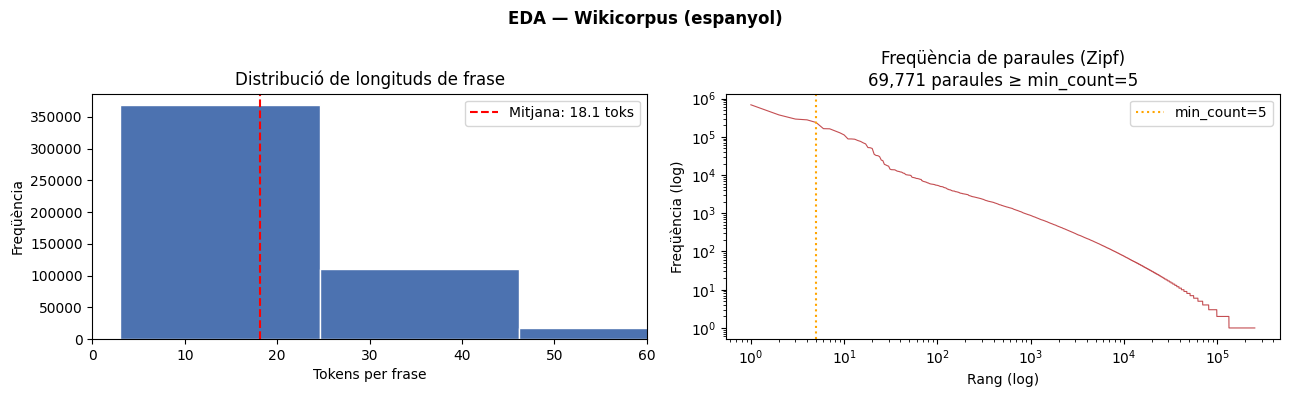

Frases            : 500,000
Tokens totals     : 9,064,865
Vocabulari únic   : 253,038
Longitud mitjana  : 18.1 toks/frase
Paraules ≥ min_count=5 (entraran al model): 69,771 (27.6%)
Top-10 paraules: [('de', 687097), ('la', 373540), ('en', 290928), ('el', 277415), ('y', 236982), ('que', 163218), ('a', 161741), ('los', 142040), ('del', 127070), ('se', 111805)]


In [23]:
import matplotlib.pyplot as plt
from collections import Counter

all_tokens   = [tok for sent in sentences for tok in sent]
vocab_counter = Counter(all_tokens)
sent_lengths  = [len(s) for s in sentences]
vocab_above   = sum(1 for f in vocab_counter.values() if f >= W2V_MIN_COUNT)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("EDA — Wikicorpus (espanyol)", fontweight="bold")

axes[0].hist(sent_lengths, bins=40, color="#4C72B0", edgecolor="white")
axes[0].axvline(sum(sent_lengths)/len(sent_lengths), color="red", linestyle="--",
                label=f"Mitjana: {sum(sent_lengths)/len(sent_lengths):.1f} toks")
axes[0].set_xlim(0, 60)
axes[0].set_title("Distribució de longituds de frase")
axes[0].set_xlabel("Tokens per frase")
axes[0].set_ylabel("Freqüència")
axes[0].legend()

freqs = sorted(vocab_counter.values(), reverse=True)
axes[1].loglog(range(1, len(freqs)+1), freqs, color="#C44E52", linewidth=0.8)
axes[1].axvline(W2V_MIN_COUNT, color="orange", linestyle=":",
                label=f"min_count={W2V_MIN_COUNT}")
axes[1].set_title(f"Freqüència de paraules (Zipf)\n"
                  f"{vocab_above:,} paraules ≥ min_count={W2V_MIN_COUNT}")
axes[1].set_xlabel("Rang (log)")
axes[1].set_ylabel("Freqüència (log)")
axes[1].legend()

plt.tight_layout()
plt.savefig("eda_wikicorpus.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Frases            : {len(sentences):,}")
print(f"Tokens totals     : {len(all_tokens):,}")
print(f"Vocabulari únic   : {len(vocab_counter):,}")
print(f"Longitud mitjana  : {sum(sent_lengths)/len(sent_lengths):.1f} toks/frase")
print(f"Paraules ≥ min_count={W2V_MIN_COUNT} (entraran al model): "
      f"{vocab_above:,} ({vocab_above/len(vocab_counter)*100:.1f}%)")
print(f"Top-10 paraules: {vocab_counter.most_common(10)}")

#### Multi-SimLex

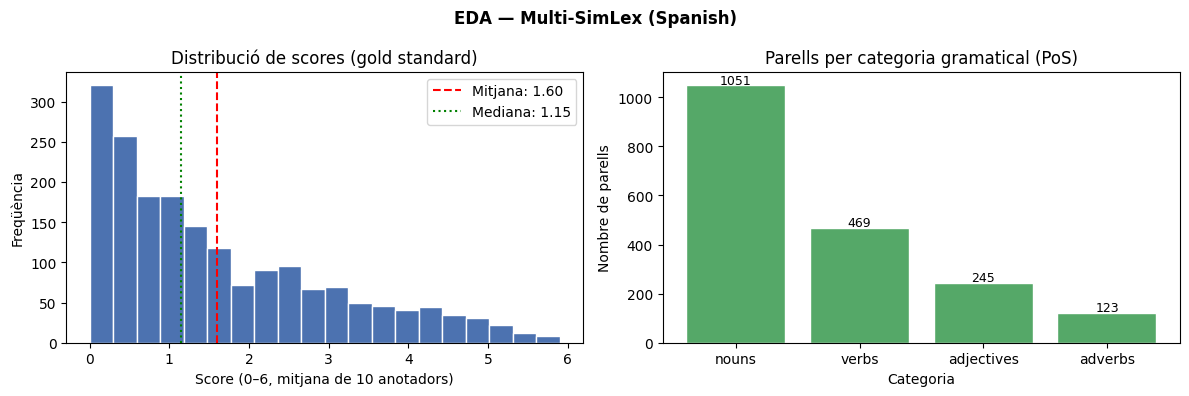

Parells totals     : 1,888
Score — mínim: 0.00 | màxim: 5.90 | mitjà: 1.60 | mediana: 1.15 | std: 1.43
Parells score = 0  (no similars) : 98
Parells score ≥ 5  (molt similars): 51


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("EDA — Multi-SimLex (Spanish)", fontweight="bold")

axes[0].hist(multisimlex_df["score"], bins=20, color="#4C72B0", edgecolor="white")
axes[0].axvline(multisimlex_df["score"].mean(), color="red", linestyle="--",
                label=f"Mitjana: {multisimlex_df['score'].mean():.2f}")
axes[0].axvline(multisimlex_df["score"].median(), color="green", linestyle=":",
                label=f"Mediana: {multisimlex_df['score'].median():.2f}")
axes[0].set_title("Distribució de scores (gold standard)")
axes[0].set_xlabel("Score (0–6, mitjana de 10 anotadors)")
axes[0].set_ylabel("Freqüència")
axes[0].legend()

pos_counts = multisimlex_df["PoS"].value_counts()
bars = axes[1].bar(pos_counts.index, pos_counts.values, color="#55A868", edgecolor="white")
for bar, v in zip(bars, pos_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 5, str(v), ha="center", fontsize=9)
axes[1].set_title("Parells per categoria gramatical (PoS)")
axes[1].set_xlabel("Categoria")
axes[1].set_ylabel("Nombre de parells")

plt.tight_layout()
plt.savefig("eda_multisimlex.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Parells totals     : {len(multisimlex_pairs):,}")
print(f"Score — mínim: {multisimlex_df['score'].min():.2f} | "
      f"màxim: {multisimlex_df['score'].max():.2f} | "
      f"mitjà: {multisimlex_df['score'].mean():.2f} | "
      f"mediana: {multisimlex_df['score'].median():.2f} | "
      f"std: {multisimlex_df['score'].std():.2f}")
print(f"Parells score = 0  (no similars) : {(multisimlex_df['score'] == 0).sum()}")
print(f"Parells score ≥ 5  (molt similars): {(multisimlex_df['score'] >= 5).sum()}")

#### Spanish STS

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("EDA — Spanish STS", fontweight="bold")

colors = {"Train": "#4C72B0", "Dev": "#55A868", "Test": "#C44E52"}
splits = {"Train": train_df,   "Dev": dev_df,    "Test": test_df}

for name, df_s in splits.items():
    axes[0].hist(df_s["score"], bins=15, alpha=0.6,
                 label=f"{name} (n={len(df_s)})", color=colors[name], edgecolor="white")
axes[0].set_title("Distribució de scores per split")
axes[0].set_xlabel("Score (0–5)")
axes[0].set_ylabel("Freqüència")
axes[0].legend()

bp = axes[1].boxplot([df_s["score"].values for df_s in splits.values()],
                     labels=splits.keys(), patch_artist=True,
                     medianprops=dict(color="white", linewidth=2))
for patch, color in zip(bp["boxes"], colors.values()):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_title("Scores per split (boxplot)")
axes[1].set_ylabel("Score (0–5)")

all_sents = pd.concat([df_s[col] for df_s in splits.values()
                        for col in ["sentence1", "sentence2"]])
lengths = all_sents.str.split().apply(len)
axes[2].hist(lengths, bins=30, color="#8172B2", edgecolor="white")
axes[2].axvline(lengths.mean(), color="red", linestyle="--",
                label=f"Mitjana: {lengths.mean():.1f} toks")
axes[2].axvline(MAX_LEN_SEQ, color="orange", linestyle=":",
                linewidth=2, label=f"MAX_LEN_SEQ={MAX_LEN_SEQ}")
axes[2].set_title("Longitud de frases (tokens)")
axes[2].set_xlabel("Nombre de tokens")
axes[2].set_ylabel("Freqüència")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig("eda_sts.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"{'Split':<8} {'N':>5}  {'min':>5} {'max':>5} {'mitjà':>7}  {'long. frase mitjana':>20}")
print("-" * 58)
for name, df_s in splits.items():
    lens = pd.concat([df_s["sentence1"], df_s["sentence2"]]).str.split().apply(len)
    print(f"{name:<8} {len(df_s):>5}  {df_s['score'].min():>5.1f} "
          f"{df_s['score'].max():>5.1f} {df_s['score'].mean():>7.3f}  "
          f"{lens.mean():>20.1f}")
pct = (lengths > MAX_LEN_SEQ).mean() * 100
print(f"\nFrases > MAX_LEN_SEQ ({MAX_LEN_SEQ}): "
      f"{(lengths > MAX_LEN_SEQ).sum()} ({pct:.1f}%) → seran truncades")

In [ ]:
# Vocabulari únic del corpus STS 
# Per estimar la cobertura dels embeddings sobre el conjunt d'avaluació
all_words_sts = set()
word_freq_sts  = Counter()
for df_s in [train_df, dev_df, test_df]:
    for col in ["sentence1", "sentence2"]:
        for sent in df_s[col]:
            toks = tokenize(sent)
            all_words_sts.update(toks)
            word_freq_sts.update(toks)

n_frases = sum(len(df_s) * 2 for df_s in [train_df, dev_df, test_df])
print(f"Frases totals (tots els splits) : {n_frases:,}")
print(f"Vocabulari únic al corpus STS   : {len(all_words_sts):,} paraules")
print(f"Top-10 paraules més freqüents   : {word_freq_sts.most_common(10)}")

## 2. Tasca 1 — Entrenament d'embeddings estàtics

Entrenem quatre models d'embeddings sobre el Wikicorpus en espanyol:

- **Word2Vec Skip-gram** amb dimensions {25, 50, 100}: captura similituds
  semàntiques per coocurrència de paraules en una finestra de context.
- **fastText Skip-gram** amb dim=100: estén Word2Vec representant cada paraula
  com la suma dels seus n-grams de caràcters (min_n=3, max_n=6), cosa que
  permet obtenir vectors per a paraules fora del vocabulari (OOV).

### 2.1 Word2Vec amb {25, 50, 100} dimensions

Skip-gram prediu les paraules de context a partir de la paraula central.
Comparem tres dimensions per analitzar com afecta la capacitat del vector
a la qualitat dels embeddings a l'avaluació intrínseca i extrínseca.

In [26]:
from gensim.models import Word2Vec

w2v_models = {}
for dim in W2V_DIMS:
    out_path = MODELS_DIR / f"w2v_skipgram_{dim}d.model"
    if out_path.exists():
        print(f"Carregant Word2Vec dim={dim} des de disc...")
        m = Word2Vec.load(str(out_path))
    else:
        print(f"Entrenant Word2Vec dim={dim}...")
        m = Word2Vec(
            sentences=sentences,
            vector_size=dim,
            window=W2V_WINDOW,       # finestra de context (±W2V_WINDOW paraules)
            min_count=W2V_MIN_COUNT, # ignora paraules amb freq < min_count
            workers=4,
            sg=1,                    # Skip-gram (millor qualitat que CBOW per corpus gran)
            epochs=W2V_EPOCHS,
            seed=SEED,
        )
        m.save(str(out_path))
    w2v_models[dim] = m
    print(f"  dim={dim:3d} | vocabulari: {len(m.wv):,} | {out_path.name}")

Entrenant Word2Vec dim=25...
  dim= 25 | vocabulari: 69,771 | w2v_skipgram_25d.model
Entrenant Word2Vec dim=50...
  dim= 50 | vocabulari: 69,771 | w2v_skipgram_50d.model
Entrenant Word2Vec dim=100...
  dim=100 | vocabulari: 69,771 | w2v_skipgram_100d.model


### 2.2 fastText propi (dim=100)

fastText estén Skip-gram descomponent cada paraula en n-grams de caràcters
(p. ex. "casa" → {"cas", "asa", "<ca", "sa>", ...}). El vector final és la
mitjana dels n-grams. Això permet:

1. Representar paraules **fora del vocabulari (OOV)** via els seus n-grams.
2. Capturar morfologia: paraules derivades comparteixen n-grams i per tant
   vectors similars (p. ex. "córrer", "corrent", "corredor").

In [ ]:
from gensim.models import FastText

ft_path = MODELS_DIR / f"fasttext_propi_{FT_DIM}d.model"

if ft_path.exists():
    print(f"Carregant fastText propi des de disc...")
    ft_propi = FastText.load(str(ft_path))
else:
    print(f"Entrenant fastText dim={FT_DIM}...")
    ft_propi = FastText(
        sentences=sentences,
        vector_size=FT_DIM,
        window=W2V_WINDOW,
        min_count=W2V_MIN_COUNT,
        workers=4,
        sg=1,       # Skip-gram
        epochs=W2V_EPOCHS,
        seed=SEED,
        min_n=3,    # longitud mínima dels n-grams de caràcters
        max_n=6,    # longitud màxima dels n-grams de caràcters
    )
    ft_propi.save(str(ft_path))

print(f"Vocabulari: {len(ft_propi.wv):,} | {ft_path.name}")

--- Entrenant fastText dim=100 ---
Vocabulari: 69,771


### 2.3 Anàlisi dels models entrenats

Inspeccionem la qualitat semàntica dels embeddings mitjançant:
1. Veïns semàntics (més similars) per a paraules de referència.
2. Test d'analogies (rei − home + dona = reina).
3. Cobertura OOV: quantes paraules del corpus STS i Multi-SimLex
   queden fora del vocabulari de cada model.

In [ ]:
# 1. Veïns semàntics
PROBE_WORDS = ["rey", "fútbol", "ordenador", "correr"]

all_kvs = {f"w2v-{d}d": m.wv for d, m in w2v_models.items()}
all_kvs["ft-propi-100d"] = ft_propi.wv

print("VEÏNS SEMÀNTICS (top-5)\n" + "=" * 65)
for word in PROBE_WORDS:
    print(f"\n  '{word}':")
    for name, kv in all_kvs.items():
        if word in kv:
            veins = [w for w, _ in kv.most_similar(word, topn=5)]
            print(f"    {name:<20} {', '.join(veins)}")
        else:
            print(f"    {name:<20} ⚠ OOV")

# 2. Test d'analogies
print("\n\nANALOGIES (rei − home + dona = ?)\n" + "=" * 65)
analogies = [
    (["rey", "mujer"], ["hombre"],  "rei−home+dona"),
    (["parís", "españa"], ["francia"], "París−França+Espanya"),
    (["correr", "nadando"], ["corriendo"], "correr−corriendo+nadando"),
]
for name, kv in all_kvs.items():
    print(f"\n  {name}:")
    for pos, neg, label in analogies:
        try:
            res = kv.most_similar(positive=pos, negative=neg, topn=1)
            print(f"    {label:<30} → {res[0][0]}  ({res[0][1]:.3f})")
        except KeyError as e:
            print(f"    {label:<30} → OOV ({e})")

# 3. Cobertura OOV
print("\n\nCOBERTURA OOV\n" + "=" * 65)

# Vocabulari de referència: tots els tokens de STS i Multi-SimLex
ref_words = all_words_sts.copy()
for w1, w2, _ in multisimlex_pairs:
    ref_words.update([w1, w2])

print(f"Paraules de referència (STS + Multi-SimLex): {len(ref_words):,}\n")
print(f"{'Model':<22} {'En vocab':>9} {'OOV':>9} {'% OOV':>8}")
print("-" * 52)
for name, kv in all_kvs.items():
    in_vocab = sum(1 for w in ref_words if w in kv)
    oov      = len(ref_words) - in_vocab
    pct_oov  = oov / len(ref_words) * 100
    print(f"{name:<22} {in_vocab:>9,} {oov:>9,} {pct_oov:>7.1f}%")

# Nota: fastText gestiona OOV via n-grams → sempre 0% OOV en producció
# El % OOV indica paraules no vistes durant l'entrenament, però fastText les pot representar igualment.

## 3. Tasca 2 — Avaluació intrínseca (Multi-SimLex)

Per a cada parell de paraules calculem la similitud cosinus dels seus embeddings i la comparem amb la puntuació humana via correlació de **Spearman**. Comparem els models propis amb el fastText oficial de Facebook i analitzem l'efecte de les paraules OOV.

### 3.1 Càrrega del fastText oficial

In [36]:
import urllib.request
import gzip
import shutil
from gensim.models.fasttext import load_facebook_model

# 1) Descàrrega del binari oficial de Facebook
FT_BIN_GZ = Path("cc.es.300.bin.gz")
FT_BIN = Path("cc.es.300.bin")

if not FT_BIN.exists():
    if not FT_BIN_GZ.exists():
        print("Descarregant fastText oficial (~4.5 GB comprimit)... pot trigar molt")
        url = "https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.es.300.bin.gz"
        urllib.request.urlretrieve(url, FT_BIN_GZ)
    print("Descomprimint...")
    with gzip.open(FT_BIN_GZ, "rb") as f_in, open(FT_BIN, "wb") as f_out:
        shutil.copyfileobj(f_in, f_out)

# 2) Càrrega amb gensim (pur Python, no necessita compilador C++)
print("Carregant model amb gensim... ocuparà ~7 GB de RAM")
ft_oficial_model = load_facebook_model(str(FT_BIN))
print(f"fastText oficial carregat. Dimensió: {ft_oficial_model.vector_size}")

Descarregant fastText oficial (~4.5 GB comprimit)... pot trigar molt
Descomprimint...
Carregant model amb gensim... ocuparà ~7 GB de RAM
fastText oficial carregat. Dimensió: 300


In [38]:
# Wrapper sobre el FastTextKeyedVectors de gensim.
# Gestiona OOV via n-grams automàticament quan accedim amb [word].
class FastTextOficialWrapper:
    def __init__(self, ft_model):
        self.kv = ft_model.wv
        self.vector_size = self.kv.vector_size
        # Vocabulari estricte: paraules vistes durant l'entrenament
        self._vocab = set(self.kv.key_to_index.keys())

    def __contains__(self, word):
        return word in self._vocab

    def __getitem__(self, word):
        # Gensim retorna sempre un vector (combinant n-grams si OOV)
        return self.kv[word]

ft_oficial = FastTextOficialWrapper(ft_oficial_model)
print(f"Vocabulari estricte fastText oficial: {len(ft_oficial._vocab):,}")

Vocabulari estricte fastText oficial: 2,000,000


### 3.2 Funció d'avaluació amb Spearman + cobertura OOV

In [39]:
def cosine_sim(v1, v2):
    n1, n2 = np.linalg.norm(v1), np.linalg.norm(v2)
    if n1 == 0 or n2 == 0:
        return 0.0
    return float(np.dot(v1, v2) / (n1 * n2))


def evaluate_multisimlex(pairs, kv, name="model", strict=True):
    """
    pairs: list de (w1, w2, gold_score)
    kv: model amb interfície [...] i `in`
    strict: si True, descarta parells amb alguna paraula OOV.
            Si False, intenta obtenir vector igualment (útil per fastText OFICIAL).
    """
    preds, golds = [], []
    n_total, n_oov_pairs, n_oov_words = 0, 0, 0
    for w1, w2, gold in pairs:
        n_total += 1
        in1 = w1 in kv
        in2 = w2 in kv
        if not in1: n_oov_words += 1
        if not in2: n_oov_words += 1
        if strict and (not in1 or not in2):
            n_oov_pairs += 1
            continue
        try:
            v1, v2 = kv[w1], kv[w2]
        except KeyError:
            n_oov_pairs += 1
            continue
        preds.append(cosine_sim(v1, v2))
        golds.append(gold)
    rho, _ = spearmanr(preds, golds) if len(preds) > 1 else (float("nan"), None)
    return {
        "model": name,
        "spearman": rho,
        "n_evaluated": len(preds),
        "n_total": n_total,
        "oov_pair_ratio": n_oov_pairs / n_total,
        "oov_word_ratio": n_oov_words / (2 * n_total),
    }

### 3.3 Avaluació de tots els models

In [40]:
# Diccionari de models a avaluar amb noms uniformes
models_intrinsic = {}
for dim, m in w2v_models.items():
    models_intrinsic[f"w2v-{dim}d"] = (m.wv, True)   # strict=True
models_intrinsic[f"ft-propi-{FT_DIM}d"] = (ft_propi.wv, True)
# fastText oficial: strict=False perquè volem aprofitar n-grams per a les OOV
models_intrinsic["ft-oficial-300d (strict)"] = (ft_oficial, True)
models_intrinsic["ft-oficial-300d (n-grams)"] = (ft_oficial, False)

simlex_results = []
for name, (kv, strict) in models_intrinsic.items():
    res = evaluate_multisimlex(multisimlex_pairs, kv, name=name, strict=strict)
    simlex_results.append(res)
    print(f"{name:35s}  ρ={res['spearman']:.4f}  "
          f"n_eval={res['n_evaluated']}/{res['n_total']}  "
          f"OOV(parell)={res['oov_pair_ratio']:.2%}")

simlex_df = pd.DataFrame(simlex_results)
simlex_df

w2v-25d                              ρ=0.2333  n_eval=1177/1888  OOV(parell)=37.66%
w2v-50d                              ρ=0.2510  n_eval=1177/1888  OOV(parell)=37.66%
w2v-100d                             ρ=0.2513  n_eval=1177/1888  OOV(parell)=37.66%
ft-propi-100d                        ρ=0.2107  n_eval=1888/1888  OOV(parell)=0.00%
ft-oficial-300d (strict)             ρ=0.5193  n_eval=1789/1888  OOV(parell)=5.24%
ft-oficial-300d (n-grams)            ρ=0.5034  n_eval=1888/1888  OOV(parell)=0.00%


,model,spearman,n_evaluated,n_total,oov_pair_ratio,oov_word_ratio
0,w2v-25d,0.233343,1177,1888,0.376589,0.225636
1,w2v-50d,0.251023,1177,1888,0.376589,0.225636
2,w2v-100d,0.251311,1177,1888,0.376589,0.225636
3,ft-propi-100d,0.210678,1888,1888,0.000000,0.000000
4,ft-oficial-300d (strict),0.519259,1789,1888,0.052436,0.027278
5,ft-oficial-300d (n-grams),0.503398,1888,1888,0.000000,0.027278


## 4. Tasca 3 — Avaluació extrínseca (Spanish STS)

Tres aproximacions a la similitud de frases:
1. **Baseline cosinus** — mitjana simple i mitjana ponderada amb TF-IDF
2. **Model seqüencial siamès** — BiLSTM + Atenció, variants `frozen` i `trainable`
3. **Model BERT siamès** — BETO + pooling + MLP de regressió

Mètrica: correlació de **Pearson** sobre el conjunt de test.

### 4.1 Baseline cosinus (mitjana simple i ponderada amb TF-IDF)

In [41]:
from sklearn.feature_extraction.text import TfidfVectorizer

def sentence_vector_mean(tokens, kv):
    vecs = [kv[t] for t in tokens if t in kv]
    if not vecs:
        return np.zeros(kv.vector_size, dtype=np.float32)
    return np.mean(vecs, axis=0)


def fit_tfidf(corpus_text):
    """Ajusta un TF-IDF sobre les frases d'un corpus."""
    vec = TfidfVectorizer(
        use_idf=True, smooth_idf=True, norm=None,
        tokenizer=tokenize, lowercase=False, token_pattern=None,
    )
    vec.fit(corpus_text)
    return vec


def sentence_vector_tfidf(text, tfidf, kv):
    row = tfidf.transform([text])
    feature_names = tfidf.get_feature_names_out()
    weighted = np.zeros(kv.vector_size, dtype=np.float32)
    total_w = 0.0
    for idx, score in zip(row.indices, row.data):
        word = feature_names[idx]
        if word in kv:
            weighted += score * kv[word]
            total_w += score
    if total_w == 0:
        return sentence_vector_mean(tokenize(text), kv)
    return weighted / total_w


def evaluate_baseline(df, kv, mode="mean", tfidf=None):
    preds = []
    for s1, s2 in zip(df["sentence1"], df["sentence2"]):
        if mode == "mean":
            v1 = sentence_vector_mean(tokenize(s1), kv)
            v2 = sentence_vector_mean(tokenize(s2), kv)
        else:
            v1 = sentence_vector_tfidf(s1, tfidf, kv)
            v2 = sentence_vector_tfidf(s2, tfidf, kv)
        preds.append(cosine_sim(v1, v2))
    pearson, _ = pearsonr(preds, df["score"])
    return pearson, preds

In [42]:
# Ajustem el TF-IDF només sobre el train per evitar fuga d'informació
all_train_sents = pd.concat([train_df["sentence1"], train_df["sentence2"]]).tolist()
tfidf = fit_tfidf(all_train_sents)
print(f"Vocabulari TF-IDF: {len(tfidf.get_feature_names_out())}")

Vocabulari TF-IDF: 11036


In [43]:
# Models a comparar com a baseline cosinus (mateixos que a la tasca 2)
baselines_kvs = {
    f"w2v-{dim}d": w2v_models[dim].wv for dim in W2V_DIMS
}
baselines_kvs[f"ft-propi-{FT_DIM}d"] = ft_propi.wv
baselines_kvs["ft-oficial-300d"] = ft_oficial   # aprofita n-grams

baseline_results = []
for name, kv in baselines_kvs.items():
    p_mean, _ = evaluate_baseline(test_df, kv, mode="mean")
    p_tfidf, _ = evaluate_baseline(test_df, kv, mode="tfidf", tfidf=tfidf)
    baseline_results.append({"model": name, "mean": p_mean, "tfidf": p_tfidf})
    print(f"{name:25s}  mean={p_mean:.4f}  tfidf={p_tfidf:.4f}")

baseline_df = pd.DataFrame(baseline_results)
baseline_df

w2v-25d                    mean=0.5401  tfidf=0.5433
w2v-50d                    mean=0.5879  tfidf=0.5601
w2v-100d                   mean=0.6108  tfidf=0.5789
ft-propi-100d              mean=0.6320  tfidf=0.5870
ft-oficial-300d            mean=0.5605  tfidf=0.6500


,model,mean,tfidf
0,w2v-25d,0.540142,0.543253
1,w2v-50d,0.587913,0.560100
2,w2v-100d,0.610814,0.578925
3,ft-propi-100d,0.632015,0.587016
4,ft-oficial-300d,0.560478,0.650032


### 4.2 Model seqüencial siamès (BiLSTM + Atenció)

#### 4.2.1 Vocabulari, matriu d'embeddings i Dataset

In [44]:
PAD_TOKEN, UNK_TOKEN = "<PAD>", "<UNK>"
PAD_IDX, UNK_IDX = 0, 1


def build_vocab_from_corpus(*dfs):
    """Construeix un vocabulari (paraula → índex) a partir de DataFrames de frases."""
    seen = set()
    for df in dfs:
        for col in ("sentence1", "sentence2"):
            for s in df[col]:
                seen.update(tokenize(s))
    vocab = {PAD_TOKEN: PAD_IDX, UNK_TOKEN: UNK_IDX}
    for w in sorted(seen):
        if w not in vocab:
            vocab[w] = len(vocab)
    return vocab


def build_embedding_matrix(vocab, kv, dim):
    """Inicialitza la matriu d'embeddings amb el KV. Mots desconeguts: aleatoris."""
    rng = np.random.default_rng(SEED)
    matrix = rng.normal(0, 0.1, size=(len(vocab), dim)).astype(np.float32)
    matrix[PAD_IDX] = 0.0
    found = 0
    for word, idx in vocab.items():
        if word in (PAD_TOKEN, UNK_TOKEN):
            continue
        if word in kv:
            matrix[idx] = kv[word]
            found += 1
    print(f"Cobertura: {found}/{len(vocab)-2} ({100*found/(len(vocab)-2):.1f}%)")
    return matrix


# Construïm el vocabulari sobre tot l'STS i una matriu a partir del fastText propi
vocab_sts = build_vocab_from_corpus(train_df, dev_df, test_df)
print(f"Vocabulari STS: {len(vocab_sts):,}")
emb_matrix = build_embedding_matrix(vocab_sts, ft_propi.wv, FT_DIM)

Vocabulari STS: 11,906
Cobertura: 11904/11904 (100.0%)


In [45]:
class STSDataset(Dataset):
    def __init__(self, df, vocab, max_len=MAX_LEN_SEQ):
        self.df = df.reset_index(drop=True)
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def encode(self, text):
        toks = tokenize(text)[: self.max_len]
        ids = [self.vocab.get(t, UNK_IDX) for t in toks]
        mask = [1] * len(ids)
        pad = self.max_len - len(ids)
        ids += [PAD_IDX] * pad
        mask += [0] * pad
        return ids, mask

    def __getitem__(self, i):
        row = self.df.iloc[i]
        ids1, m1 = self.encode(row["sentence1"])
        ids2, m2 = self.encode(row["sentence2"])
        return {
            "input_ids_1": torch.tensor(ids1, dtype=torch.long),
            "attention_mask_1": torch.tensor(m1, dtype=torch.bool),
            "input_ids_2": torch.tensor(ids2, dtype=torch.long),
            "attention_mask_2": torch.tensor(m2, dtype=torch.bool),
            "score": torch.tensor(float(row["score"]), dtype=torch.float),
        }


train_ds = STSDataset(train_df, vocab_sts)
dev_ds   = STSDataset(dev_df,   vocab_sts)
test_ds  = STSDataset(test_df,  vocab_sts)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
dev_loader   = DataLoader(dev_ds,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE)
print(f"Batches train/dev/test: {len(train_loader)}/{len(dev_loader)}/{len(test_loader)}")

Batches train/dev/test: 42/3/5


#### 4.2.2 Arquitectura siamesa (segons l'enunciat)

In [46]:
class AttentionPooling(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x, mask):
        scores = self.proj(x).squeeze(-1)
        scores = scores.masked_fill(~mask, -1e9)
        alpha = torch.softmax(scores, dim=-1)
        return torch.sum(x * alpha.unsqueeze(-1), dim=1)


class SiameseBiLSTMAttention(nn.Module):
    def __init__(self, embedding_matrix, hidden_size=64, final_hidden_size=32,
                 trainable_embeddings=False):
        super().__init__()
        self.embedding = nn.Embedding.from_pretrained(
            torch.tensor(embedding_matrix, dtype=torch.float),
            freeze=not trainable_embeddings,
            padding_idx=PAD_IDX,
        )
        emb_dim = embedding_matrix.shape[1]
        self.encoder = nn.LSTM(
            emb_dim, hidden_size, batch_first=True, bidirectional=True
        )
        self.pool = AttentionPooling(hidden_size * 2)
        self.regressor = nn.Sequential(
            nn.Linear(hidden_size * 2 * 4, final_hidden_size),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(final_hidden_size, 1),
        )

    def encode(self, input_ids, attention_mask):
        x = self.embedding(input_ids)
        x, _ = self.encoder(x)
        return self.pool(x, attention_mask)

    def forward(self, input_ids_1, attention_mask_1, input_ids_2, attention_mask_2):
        h1 = self.encode(input_ids_1, attention_mask_1)
        h2 = self.encode(input_ids_2, attention_mask_2)
        feats = torch.cat([h1, h2, torch.abs(h1 - h2), h1 * h2], dim=-1)
        return self.regressor(feats).squeeze(-1)

#### 4.2.3 Bucle d'entrenament i avaluació

In [47]:
def evaluate_pearson(model, loader):
    model.eval()
    preds, golds = [], []
    with torch.no_grad():
        for batch in loader:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            p = model(batch["input_ids_1"], batch["attention_mask_1"],
                      batch["input_ids_2"], batch["attention_mask_2"])
            preds.extend(p.cpu().numpy().tolist())
            golds.extend(batch["score"].cpu().numpy().tolist())
    return pearsonr(preds, golds)[0]


def train_regressor(model, train_loader, dev_loader, epochs, lr, name="model"):
    model.to(DEVICE)
    optim = torch.optim.AdamW(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    best_dev, best_state = -1.0, None

    for ep in range(epochs):
        model.train()
        total = 0.0
        for batch in train_loader:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            optim.zero_grad()
            preds = model(batch["input_ids_1"], batch["attention_mask_1"],
                          batch["input_ids_2"], batch["attention_mask_2"])
            loss = loss_fn(preds, batch["score"])
            loss.backward()
            optim.step()
            total += loss.item()
        dev_p = evaluate_pearson(model, dev_loader)
        print(f"[{name}] epoch {ep+1}/{epochs}  "
              f"train_loss={total/len(train_loader):.4f}  dev_pearson={dev_p:.4f}")
        if dev_p > best_dev:
            best_dev = dev_p
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    return model, best_dev

#### 4.2.4 Variants `frozen` i `trainable` (suggerides per l'enunciat)

In [48]:
# Variant A: embeddings congelats
torch.manual_seed(SEED)
siamese_frozen = SiameseBiLSTMAttention(emb_matrix, trainable_embeddings=False)
siamese_frozen, dev_frozen = train_regressor(
    siamese_frozen, train_loader, dev_loader,
    epochs=SIAMESE_EPOCHS, lr=SIAMESE_LR, name="siamese-frozen",
)
test_frozen = evaluate_pearson(siamese_frozen, test_loader)
print(f"\n→ Pearson test (frozen): {test_frozen:.4f}")

[siamese-frozen] epoch 1/10  train_loss=2.3098  dev_pearson=0.1850
[siamese-frozen] epoch 2/10  train_loss=1.0968  dev_pearson=0.2716
[siamese-frozen] epoch 3/10  train_loss=1.1318  dev_pearson=0.3251
[siamese-frozen] epoch 4/10  train_loss=1.0901  dev_pearson=0.3799
[siamese-frozen] epoch 5/10  train_loss=1.0309  dev_pearson=0.4213
[siamese-frozen] epoch 6/10  train_loss=0.9944  dev_pearson=0.4639
[siamese-frozen] epoch 7/10  train_loss=0.9494  dev_pearson=0.5185
[siamese-frozen] epoch 8/10  train_loss=0.8651  dev_pearson=0.5284
[siamese-frozen] epoch 9/10  train_loss=0.8398  dev_pearson=0.5780
[siamese-frozen] epoch 10/10  train_loss=0.7805  dev_pearson=0.6073

→ Pearson test (frozen): 0.6126


In [49]:
# Variant B: embeddings entrenables (fine-tuning de la matriu)
torch.manual_seed(SEED)
siamese_train = SiameseBiLSTMAttention(emb_matrix, trainable_embeddings=True)
siamese_train, dev_train = train_regressor(
    siamese_train, train_loader, dev_loader,
    epochs=SIAMESE_EPOCHS, lr=SIAMESE_LR, name="siamese-trainable",
)
test_train = evaluate_pearson(siamese_train, test_loader)
print(f"\n→ Pearson test (trainable): {test_train:.4f}")

[siamese-trainable] epoch 1/10  train_loss=2.3062  dev_pearson=0.1954
[siamese-trainable] epoch 2/10  train_loss=1.0832  dev_pearson=0.2787
[siamese-trainable] epoch 3/10  train_loss=1.0899  dev_pearson=0.3314
[siamese-trainable] epoch 4/10  train_loss=0.9563  dev_pearson=0.3488
[siamese-trainable] epoch 5/10  train_loss=0.7448  dev_pearson=0.3164
[siamese-trainable] epoch 6/10  train_loss=0.4665  dev_pearson=0.3103
[siamese-trainable] epoch 7/10  train_loss=0.3699  dev_pearson=0.3492
[siamese-trainable] epoch 8/10  train_loss=0.2941  dev_pearson=0.3635
[siamese-trainable] epoch 9/10  train_loss=0.2183  dev_pearson=0.3237
[siamese-trainable] epoch 10/10  train_loss=0.2169  dev_pearson=0.3424

→ Pearson test (trainable): 0.4582


### 4.3 Model BERT siamès (BETO)

In [51]:
from transformers import AutoTokenizer, AutoModel

bert_tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL_NAME)


class STSBertDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=MAX_LEN_SEQ):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, i):
        row = self.df.iloc[i]
        e1 = self.tokenizer(row["sentence1"], truncation=True,
                            padding="max_length", max_length=self.max_len,
                            return_tensors="pt")
        e2 = self.tokenizer(row["sentence2"], truncation=True,
                            padding="max_length", max_length=self.max_len,
                            return_tensors="pt")
        return {
            "input_ids_1": e1["input_ids"].squeeze(0),
            "attention_mask_1": e1["attention_mask"].squeeze(0),
            "input_ids_2": e2["input_ids"].squeeze(0),
            "attention_mask_2": e2["attention_mask"].squeeze(0),
            "score": torch.tensor(float(row["score"]), dtype=torch.float),
        }


bert_train = DataLoader(STSBertDataset(train_df, bert_tokenizer), batch_size=16, shuffle=True)
bert_dev   = DataLoader(STSBertDataset(dev_df,   bert_tokenizer), batch_size=16)
bert_test  = DataLoader(STSBertDataset(test_df,  bert_tokenizer), batch_size=16)

config.json:   0%|          | 0.00/648 [00:00<?, ?B/s]

c:\Users\irenm\PLH\plh\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\irenm\.cache\huggingface\hub\models--dccuchile--bert-base-spanish-wwm-cased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


tokenizer_config.json:   0%|          | 0.00/364 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/134 [00:00<?, ?B/s]

In [52]:
class MeanPooling(nn.Module):
    def forward(self, last_hidden_state, attention_mask):
        mask = attention_mask.unsqueeze(-1).float()
        x = last_hidden_state * mask
        return x.sum(dim=1) / mask.sum(dim=1).clamp(min=1e-9)


class BETOSiameseRegressor(nn.Module):
    def __init__(self, model_name=BERT_MODEL_NAME, final_hidden_size=128):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        self.pool = MeanPooling()
        hidden = self.encoder.config.hidden_size
        self.regressor = nn.Sequential(
            nn.Linear(hidden * 4, final_hidden_size),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(final_hidden_size, 1),
        )

    def encode(self, input_ids, attention_mask):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        return self.pool(out.last_hidden_state, attention_mask)

    def forward(self, input_ids_1, attention_mask_1, input_ids_2, attention_mask_2):
        h1 = self.encode(input_ids_1, attention_mask_1)
        h2 = self.encode(input_ids_2, attention_mask_2)
        feats = torch.cat([h1, h2, torch.abs(h1 - h2), h1 * h2], dim=-1)
        return self.regressor(feats).squeeze(-1)

In [53]:
torch.manual_seed(SEED)
beto_model = BETOSiameseRegressor()
beto_model, dev_bert = train_regressor(
    beto_model, bert_train, bert_dev,
    epochs=BERT_EPOCHS, lr=BERT_LR, name="beto-siamese",
)
test_bert = evaluate_pearson(beto_model, bert_test)
print(f"\n→ Pearson test (BETO siamès): {test_bert:.4f}")

pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
pooler.dense.bias                          | MISSING    | 
pooler.dense.weight                        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

[beto-siamese] epoch 1/4  train_loss=1.3351  dev_pearson=0.3451
[beto-siamese] epoch 2/4  train_loss=0.9380  dev_pearson=0.5794
[beto-siamese] epoch 3/4  train_loss=0.5292  dev_pearson=0.6941
[beto-siamese] epoch 4/4  train_loss=0.2576  dev_pearson=0.6993

→ Pearson test (BETO siamès): 0.7063


## 5. Anàlisi opcional — Robustesa a pertorbacions

Construïm tres versions pertorbades del test STS (sense accents, errors tipogràfics, lowercase agressiu) per veure com es degrada cada model. L'enunciat suggereix aquesta anàlisi com a opcional.

In [54]:
def remove_accents(text):
    return "".join(
        c for c in unicodedata.normalize("NFD", text)
        if unicodedata.category(c) != "Mn"
    )


def add_typos(text, prob=0.10, rng=None):
    if rng is None:
        rng = random.Random(SEED)
    chars = list(text)
    out = []
    i = 0
    while i < len(chars):
        c = chars[i]
        if c.isalpha() and rng.random() < prob:
            op = rng.choice(["swap", "delete", "duplicate"])
            if op == "swap" and i + 1 < len(chars) and chars[i+1].isalpha():
                out.append(chars[i+1]); out.append(c); i += 2; continue
            elif op == "delete":
                i += 1; continue
            elif op == "duplicate":
                out.append(c); out.append(c); i += 1; continue
        out.append(c); i += 1
    return "".join(out)


def perturb_df(df, mode):
    df_p = df.copy()
    rng = random.Random(SEED)
    if mode == "no_accents":
        df_p["sentence1"] = df_p["sentence1"].apply(remove_accents)
        df_p["sentence2"] = df_p["sentence2"].apply(remove_accents)
    elif mode == "typos":
        df_p["sentence1"] = df_p["sentence1"].apply(lambda t: add_typos(t, 0.10, random.Random(SEED)))
        df_p["sentence2"] = df_p["sentence2"].apply(lambda t: add_typos(t, 0.10, random.Random(SEED+1)))
    return df_p


# Generem les variants pertorbades del test
test_clean   = test_df
test_no_acc  = perturb_df(test_df, "no_accents")
test_typos   = perturb_df(test_df, "typos")

print("Original :", test_clean.iloc[0]["sentence1"])
print("Sense ac.:", test_no_acc.iloc[0]["sentence1"])
print("Typos    :", test_typos.iloc[0]["sentence1"])

Original : El viceministro de Política Interior y Seguridad Jurídica, José Vicente Rangel Ávalos, señaló que antes de que el pueblo eligiera al presidente Hugo Chávez, “La tortura estaba institucionalizada y el asesinato político era frecuente” en Venezuela.
Sense ac.: El viceministro de Politica Interior y Seguridad Juridica, Jose Vicente Rangel Avalos, senalo que antes de que el pueblo eligiera al presidente Hugo Chavez, “La tortura estaba institucionalizada y el asesinato politico era frecuente” en Venezuela.
Typos    : E vicemiinstor de Política Interio y Seguridad Jurídica, José VVicente Range Ávvalos, señaló que antse de que el pueblo eligierra al presidente Hgo Chávez, “LLa ttortura estaba institucionnlaizdaa y el asesinnato poltico era freeccuente” en Vezuela.


In [55]:
# Re-avaluació dels baselines cosinus (mean) sobre les 3 versions del test
robustness_rows = []
for name, kv in baselines_kvs.items():
    row = {"model": name}
    for split_name, split_df in [("clean", test_clean),
                                  ("no_accents", test_no_acc),
                                  ("typos", test_typos)]:
        p, _ = evaluate_baseline(split_df, kv, mode="mean")
        row[split_name] = p
    robustness_rows.append(row)

robustness_df = pd.DataFrame(robustness_rows)
robustness_df["delta_no_acc"] = robustness_df["clean"] - robustness_df["no_accents"]
robustness_df["delta_typos"]  = robustness_df["clean"] - robustness_df["typos"]
robustness_df

,model,clean,no_accents,typos,delta_no_acc,delta_typos
0,w2v-25d,0.540142,0.550337,0.402585,-0.010195,0.137557
1,w2v-50d,0.587913,0.600246,0.447950,-0.012333,0.139963
2,w2v-100d,0.610814,0.617734,0.445475,-0.006920,0.165339
3,ft-propi-100d,0.632015,0.631708,0.544732,0.000307,0.087283
4,ft-oficial-300d,0.560478,0.559054,0.490818,0.001424,0.069661


## 6. Resum de resultats

Reagrupem tots els números en taules úniques per facilitar la redacció de l'informe.

In [56]:
print("="*70)
print("TASCA 2 — Multi-SimLex (Spearman)")
print("="*70)
print(simlex_df.to_string(index=False))

print("\n" + "="*70)
print("TASCA 3 — Spanish STS (Pearson)")
print("="*70)
sts_summary = baseline_df.copy()
sts_summary = sts_summary.rename(columns={"mean": "baseline_mean", "tfidf": "baseline_tfidf"})
print("\n[Baseline cosinus]")
print(sts_summary.to_string(index=False))

print("\n[Models neurals — test Pearson]")
print(f"  siamese-frozen     : {test_frozen:.4f}  (dev: {dev_frozen:.4f})")
print(f"  siamese-trainable  : {test_train:.4f}  (dev: {dev_train:.4f})")
print(f"  beto-siamese       : {test_bert:.4f}   (dev: {dev_bert:.4f})")

print("\n" + "="*70)
print("ROBUSTESA — Pearson amb test pertorbat (baseline mean)")
print("="*70)
print(robustness_df.to_string(index=False))

TASCA 2 — Multi-SimLex (Spearman)
                    model  spearman  n_evaluated  n_total  oov_pair_ratio  oov_word_ratio
                  w2v-25d  0.233343         1177     1888        0.376589        0.225636
                  w2v-50d  0.251023         1177     1888        0.376589        0.225636
                 w2v-100d  0.251311         1177     1888        0.376589        0.225636
            ft-propi-100d  0.210678         1888     1888        0.000000        0.000000
 ft-oficial-300d (strict)  0.519259         1789     1888        0.052436        0.027278
ft-oficial-300d (n-grams)  0.503398         1888     1888        0.000000        0.027278

TASCA 3 — Spanish STS (Pearson)

[Baseline cosinus]
          model  baseline_mean  baseline_tfidf
        w2v-25d       0.540142        0.543253
        w2v-50d       0.587913        0.560100
       w2v-100d       0.610814        0.578925
  ft-propi-100d       0.632015        0.587016
ft-oficial-300d       0.560478        0.650032



In [57]:
# Guardem totes les taules per poder-les recuperar més tard a l'informe
RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

simlex_df.to_csv(RESULTS_DIR / "simlex_results.csv", index=False)
baseline_df.to_csv(RESULTS_DIR / "sts_baseline_results.csv", index=False)
robustness_df.to_csv(RESULTS_DIR / "robustness_results.csv", index=False)

neural_results = pd.DataFrame([
    {"model": "siamese-frozen",    "dev_pearson": dev_frozen, "test_pearson": test_frozen},
    {"model": "siamese-trainable", "dev_pearson": dev_train,  "test_pearson": test_train},
    {"model": "beto-siamese",      "dev_pearson": dev_bert,   "test_pearson": test_bert},
])
neural_results.to_csv(RESULTS_DIR / "sts_neural_results.csv", index=False)
print("Resultats guardats a", RESULTS_DIR)

Resultats guardats a results
